# Oppgave 2: Forsikringskrav

## Oppgave 2a: Antall forsikringskrav

Vi lar $X(t)$ være antall forsikringshenvendelser et forsikringsselskap har motatt i et tidsinterval $[0, t]$. Vi kan anta at ${X(t) : t \geq 0}$ er en Poissonprosess hvor $t$ er tiden målt fra 1. januar kl. 00:00.00 med $\lambda (t) = 1.5 , t \geq 0$

$P(X(59) > 100), X(t)$ ~ $Poisson(\lambda t)$

In [6]:
from scipy.stats import poisson
lambda_t = 1.5 * 59
theoretical_prob = 1 - poisson.cdf(100, lambda_t)
print(f'{(theoretical_prob * 100):.2f} %')

10.28 %


Sannsynligheten for mer enn 100 henvendelser innen 1. mars er $10.28$

In [20]:
import numpy as np

num_simulations = 1000
num_runs = 10  

theoretical_prob = 1 - poisson.cdf(100, lambda_t)

simulated_probs = []

for run in range(num_runs):
    X_simulations = np.random.poisson(lambda_t, num_simulations)
    count_greater_than_100 = np.sum(X_simulations > 100)
    sim_prob = count_greater_than_100 / num_simulations
    simulated_probs.append(sim_prob)

avg_simulated_prob = np.mean(simulated_probs)
std_error = np.std(simulated_probs) / np.sqrt(num_runs)

ci_lower = avg_simulated_prob - 1.96 * std_error
ci_upper = avg_simulated_prob + 1.96 * std_error

# Results
print(f"Theoretical P(X > 100):  {theoretical_prob:.6f}")
print(f"Simulated P (averaged):  {avg_simulated_prob:.6f}")
print(f"95% CI:                  [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"Error:                   {abs(avg_simulated_prob - theoretical_prob)/theoretical_prob * 100:.2f}%")

Theoretical P(X > 100):  0.102822
Simulated P (averaged):  0.103500
95% CI:                  [0.097777, 0.109223]
Error:                   0.66%


For å bekrefte den teoretiske verdien har vi kjørt 10 uavhengige Monte Carlo simuleringer. Gjennomsnittsverdien av sannsynligheten fra simuleringene er $0.035$ som faller innenfor  95% konfidensintervallet $[0.097777, 0.109223]$ og har et avvik på $0.66$ % fra den teoretiske verdien. Vi kan dermed bekrefte den teoretiske verdien

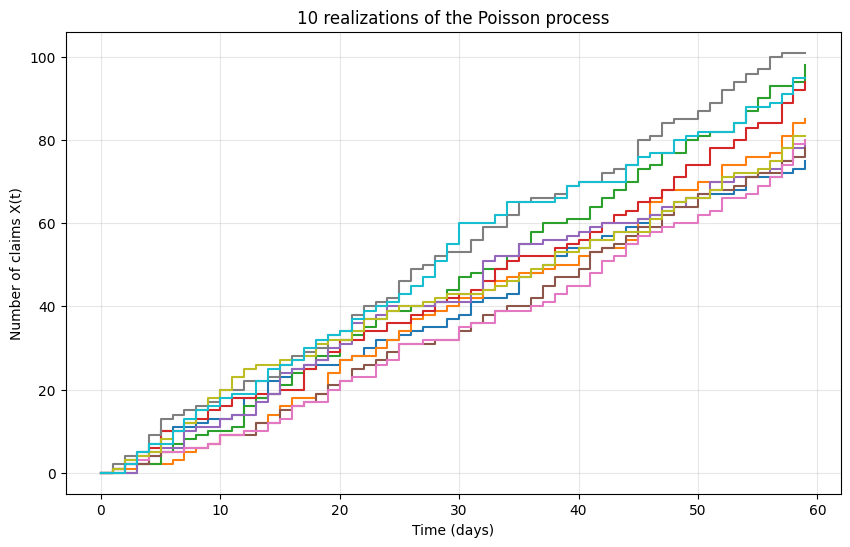

In [23]:
import matplotlib.pyplot as plt

increments = np.random.poisson(1.5, size=(10, 59))

X_paths = np.cumsum(increments, axis=1)
X_paths = np.column_stack((np.zeros(10), X_paths))
t = np.arange(60)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.step(t, X_paths[i], where="post")

plt.xlabel("Time (days)")
plt.ylabel("Number of claims X(t)")
plt.title("10 realizations of the Poisson process")
plt.grid(True, alpha=0.3)
plt.show()

Vi ser at for disse 10 simuleringene, er det kun en som har over 100 henvendelser. Dette samsvarer godt med den utregnede sannsynligheten på rett over $10$ %

## Oppgave 2b: Samlet kravbelop

Skriv resultatet og diskusjonen her.

## Oppgave 2c: Tynning av Poisson-prosessen

Skriv beviset og beregningen av raten her.